Epoch 1/20


c:\Users\mayan\OneDrive\Desktop\traffic flow prediction\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.5233 - val_loss: 0.2782
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2976 - val_loss: 0.2966
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.3086 - val_loss: 0.2731
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2774 - val_loss: 0.2762
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.2890 - val_loss: 0.2783
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2751 - val_loss: 0.2714
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2784 - val_loss: 0.2724
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2961 - val_loss: 0.2718
Epoch 9/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.2703 - val_loss: 0.2712
Epoch 10/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2741 - val_loss: 0.2694
Epoch 11/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.2885 - val_loss: 0.2690
Epoch 12/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.2473 - val_loss: 0.2812
Epoch 13/20


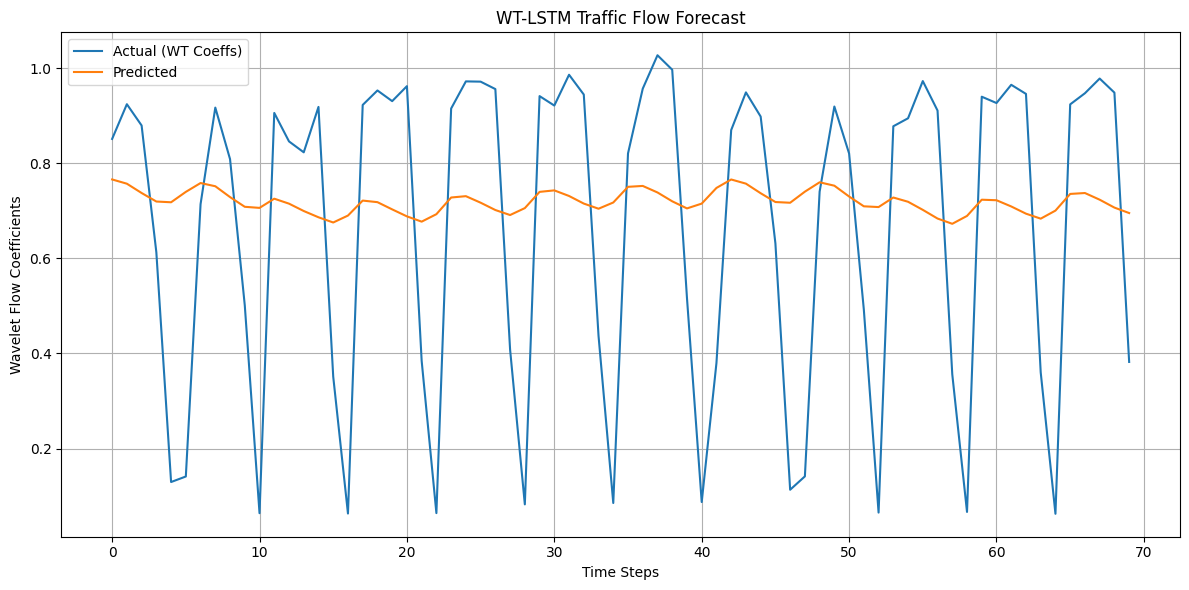

In [1]:
import pandas as pd
import numpy as np
import pywt
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Step 1: Load traffic data
df = pd.read_csv("traffic_2hr_intervals.csv", parse_dates=["datetime"])
df.sort_values(by=["location", "datetime"], inplace=True)

# Step 2: Choose a location
location_id = df["location"].unique()[0]
df_location = df[df["location"] == location_id]

# Step 3: Scale 'flow' feature
flow = df_location['flow'].values.reshape(-1, 1)
scaler = MinMaxScaler()
flow_scaled = scaler.fit_transform(flow).flatten()

# Step 4: Apply Wavelet Transform (DWT)
cA, cD = pywt.dwt(flow_scaled, 'db1')  # 'db1' = Haar wavelet
wt_flow = cA  # You can use cA only or concatenate with cD

# Step 5: Create sequences
def create_sequences(series, seq_len):
    X, y = [], []
    for i in range(len(series) - seq_len):
        X.append(series[i:i+seq_len])
        y.append(series[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 24  # 2 days of 2hr intervals
X, y = create_sequences(wt_flow, sequence_length)
X = X.reshape((X.shape[0], X.shape[1], 1))

# Step 6: Split into train and test
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Step 7: Build WT-LSTM model
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(64))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mae')

# Step 8: Train model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, batch_size=32)

# Step 9: Predict and evaluate
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"WT-LSTM MAE: {mae:.3f}")
print(f"WT-LSTM RMSE: {rmse:.3f}")

# Step 10: Plot predictions
plt.figure(figsize=(12, 6))
plt.plot(y_test[:200], label="Actual (WT Coeffs)")
plt.plot(y_pred[:200], label="Predicted")
plt.title("WT-LSTM Traffic Flow Forecast")
plt.xlabel("Time Steps")
plt.ylabel("Wavelet Flow Coefficients")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
